# Clasificador de Edad por DÉCADA — UTKFace

Clasificación multiclase (**9 clases** por década) a partir de imágenes de rostros, implementado en **PyTorch** y **TensorFlow/Keras**.

**Categorías de edad:**

| Clase | Rango |
|---|---|
| 0 | 0–9 |
| 1 | 10–19 |
| 2 | 20–29 |
| 3 | 30–39 |
| 4 | 40–49 |
| 5 | 50–59 |
| 6 | 60–69 |
| 7 | 70–79 |
| 8 | 80+ |

> ## 📌 Banco de entrenamiento: dataset_decadas (BALANCEADO por década)
>
> Este notebook entrena sobre un banco **balanceado por década de edad**, armado a partir de UTKFace:
> - Carpeta: `./UTKFace_data/dataset_decadas`
> - Una subcarpeta por clase (`0-9`, `10-19`, …, `80+`) con **673 imágenes cada una** → **6.057 imágenes** en total.
> - 673 = tamaño de la categoría más chica (**80+**), que fija el balance perfecto entre clases.
> - La etiqueta se toma del **nombre de la carpeta**. La carpeta `sobrantes` (17.648 img) se **excluye**.
>
> **Etnia por categoría (de las fotos elegidas):** aunque el banco está balanceado por *edad*, la composición *étnica* varía mucho entre categorías (ver celda "Distribución por etnia"). Códigos UTKFace: `White, Black, Asian, Indian, Others` (los latinos/hispanos caen en **Others**; UTKFace no tiene etiqueta propia para ellos).
>
> ⚠️ **Sesgo a tener presente:** como la mezcla étnica difiere por edad, el modelo podría apoyarse en rasgos étnicos para predecir la edad.
>
> 👉 Otros notebooks: `clasificador_edad_utkface.ipynb` (5 clases balanceado) y `clasificador_edad_utkface_RESULTADOS_completo.ipynb` (5 clases, UTKFace completo desbalanceado).

## 0. Descarga del dataset (UTKFace)

**Opción A — Kaggle API (recomendado):**

```bash
pip install kaggle
# 1. Crea una cuenta en kaggle.com si no tienes
# 2. Ve a kaggle.com/settings -> API -> "Create New Token" (descarga kaggle.json)
# 3. Coloca kaggle.json en ~/.kaggle/kaggle.json (Linux/Mac) o C:\Users\<usuario>\.kaggle\kaggle.json (Windows)

kaggle datasets download -d jangedoo/utkface-new
unzip utkface-new.zip -d ./UTKFace_data
```

**Opción B — Descarga manual:**

1. Ve a https://www.kaggle.com/datasets/jangedoo/utkface-new
2. Descarga el .zip (botón Download)
3. Descomprime y deja la carpeta de imágenes en `./UTKFace_data/UTKFace/` (debe contener directamente los .jpg, sin subcarpetas extra)

**Estructura esperada:**
```
UTKFace_data/
  UTKFace/
    1_0_0_20161219140623097.jpg
    2_1_3_20170109150557335.jpg
    ...
```

El nombre de cada archivo sigue el formato `[edad]_[género]_[raza]_[fecha].jpg`. Solo usaremos el campo `edad`.

In [1]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/dataset_decadas"   # banco BALANCEADO por DÉCADA (una subcarpeta por clase)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [2]:
# --- Categorías por década y utilidades ---
CLASS_NAMES = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

# Códigos de etnia de UTKFace (campo 3 del nombre de archivo)
RACE_NAMES = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}

def parse_race_from_filename(filename: str):
    """Extrae el código de etnia (0-4) del nombre '[edad]_[genero]_[raza]_[fecha].jpg'. None si no calza."""
    parts = os.path.basename(filename).split("_")
    try:
        race = int(parts[2])
        return race if race in RACE_NAMES else None
    except (ValueError, IndexError):
        return None

In [3]:
# --- Construcción del dataframe desde dataset_decadas (banco BALANCEADO por década) ---
# La etiqueta se toma del NOMBRE DE LA SUBCARPETA (0-9, 10-19, ..., 80+).
# La carpeta 'sobrantes' NO está en CLASS_NAMES, por lo que queda excluida.
# Además guardamos la etnia (del nombre de archivo) para el análisis posterior.
records = []
for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_DIR, class_name)
    fps = glob.glob(os.path.join(class_dir, "*.jpg"))
    if len(fps) == 0:
        raise FileNotFoundError(
            f"No hay imágenes en '{class_dir}'. Revisa que exista dataset_decadas "
            "con una subcarpeta por década (0-9 ... 80+)."
        )
    for fp in fps:
        records.append({"filepath": fp, "label": label_idx, "race": parse_race_from_filename(fp)})

df = pd.DataFrame(records, columns=["filepath", "label", "race"])
print(f"Imágenes cargadas (banco por década): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes cargadas (banco por década): 6057
Por clase:
label
0-9      673
10-19    673
20-29    673
30-39    673
40-49    673
50-59    673
60-69    673
70-79    673
80+      673
Name: count, dtype: int64


,filepath,label,race
0,./UTKFace_data/dataset_decadas\0-9\1_0_0_20161...,0,0
1,./UTKFace_data/dataset_decadas\0-9\1_0_0_20161...,0,0
2,./UTKFace_data/dataset_decadas\0-9\1_0_0_20161...,0,0
3,./UTKFace_data/dataset_decadas\0-9\1_0_0_20161...,0,0
4,./UTKFace_data/dataset_decadas\0-9\1_0_0_20161...,0,0


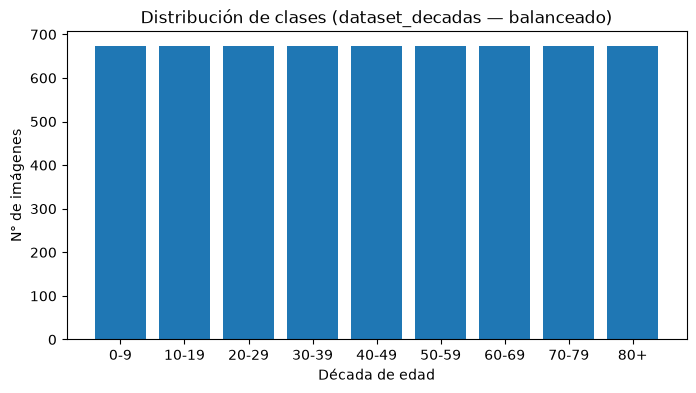

label
0-9      673
10-19    673
20-29    673
30-39    673
40-49    673
50-59    673
60-69    673
70-79    673
80+      673
Name: count, dtype: int64


In [4]:
# --- Distribución de clases (por década) ---
counts = df["label"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=0)
plt.figure(figsize=(8, 4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Distribución de clases (dataset_decadas — balanceado)")
plt.ylabel("N° de imágenes")
plt.xlabel("Década de edad")
plt.show()

print(counts.rename(index=lambda i: CLASS_NAMES[i]))
# Banco balanceado: 673 imágenes por década -> barras del mismo alto.

Distribución de etnia por categoría de edad (%):

race_name  White  Black  Asian  Indian  Others
0-9         34.5    4.6   31.4    16.9    12.6
10-19       61.8   10.1    5.8    10.4    11.9
20-29       27.8   25.3   18.1    19.9     8.9
30-39       40.9   26.4   12.5    15.9     4.3
40-49       51.0   19.8    6.7    17.1     5.5
50-59       59.3   15.5    5.3    18.0     1.9
60-69       66.7   15.2    6.5    10.8     0.7
70-79       68.6   12.5   12.0     6.5     0.3
80+         71.8    8.6   15.2     3.9     0.6


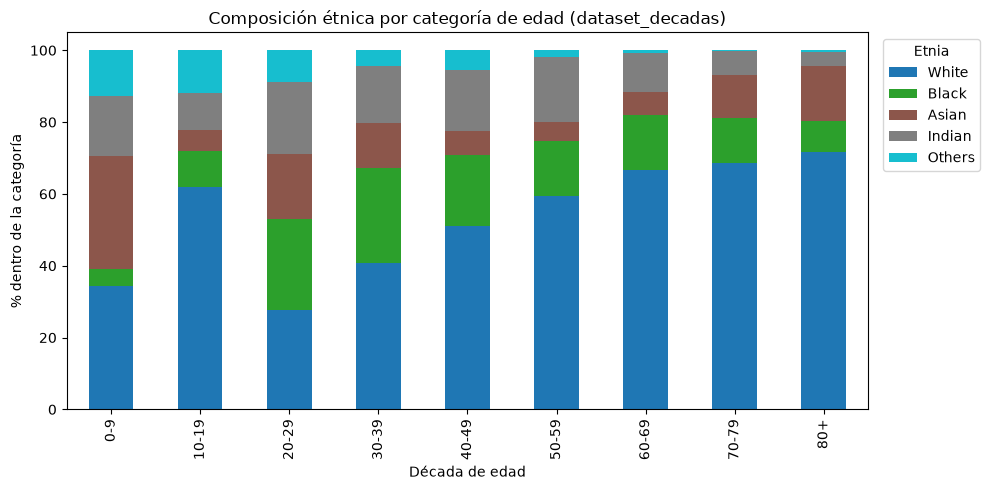

In [5]:
# --- Distribución por ETNIA dentro de cada categoría de edad ---
# Porcentaje de cada etnia (columnas) en cada década (filas).
tab = (
    df.assign(race_name=df["race"].map(RACE_NAMES))
      .pivot_table(index="label", columns="race_name", aggfunc="size", fill_value=0)
      .reindex(range(len(CLASS_NAMES)))
)
tab.index = [CLASS_NAMES[i] for i in tab.index]
tab = tab.reindex(columns=[RACE_NAMES[r] for r in range(5)], fill_value=0)

pct = tab.div(tab.sum(axis=1), axis=0) * 100  # % por fila

print("Distribución de etnia por categoría de edad (%):\n")
print(pct.round(1).to_string())

# Gráfico de barras apiladas (100% por categoría)
ax = pct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab10")
ax.set_title("Composición étnica por categoría de edad (dataset_decadas)")
ax.set_ylabel("% dentro de la categoría")
ax.set_xlabel("Década de edad")
ax.legend(title="Etnia", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Nota: 'Others' incluye hispanos/latinos; UTKFace no tiene etiqueta 'Latino' propia.

In [6]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 4239  |  Val: 909  |  Test: 909


## Parte A — PyTorch

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [8]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=9, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [9]:
# --- Entrenamiento (PyTorch) ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

Epoch 1/10 | train_loss=2.0536 train_acc=0.2090 | val_loss=1.8185 val_acc=0.2992


Epoch 2/10 | train_loss=1.7258 train_acc=0.3201 | val_loss=1.6277 val_acc=0.3377


Epoch 3/10 | train_loss=1.5768 train_acc=0.3708 | val_loss=1.5599 val_acc=0.3718


Epoch 4/10 | train_loss=1.5049 train_acc=0.3963 | val_loss=1.5298 val_acc=0.3839


Epoch 5/10 | train_loss=1.4262 train_acc=0.4263 | val_loss=1.5071 val_acc=0.3729


Epoch 6/10 | train_loss=1.3524 train_acc=0.4525 | val_loss=1.4959 val_acc=0.3850


Epoch 7/10 | train_loss=1.2646 train_acc=0.4919 | val_loss=1.4451 val_acc=0.4048


Epoch 8/10 | train_loss=1.1841 train_acc=0.5197 | val_loss=1.5289 val_acc=0.4004


Epoch 9/10 | train_loss=1.1214 train_acc=0.5428 | val_loss=1.5094 val_acc=0.4004


Epoch 10/10 | train_loss=1.0272 train_acc=0.5900 | val_loss=1.5572 val_acc=0.3949


              precision    recall  f1-score   support

         0-9       0.87      0.78      0.82       101
       10-19       0.55      0.37      0.44       101
       20-29       0.36      0.52      0.43       101
       30-39       0.24      0.29      0.26       101
       40-49       0.27      0.31      0.29       101
       50-59       0.23      0.20      0.21       101
       60-69       0.32      0.29      0.30       101
       70-79       0.34      0.26      0.29       101
         80+       0.57      0.64      0.60       101

    accuracy                           0.41       909
   macro avg       0.42      0.41      0.41       909
weighted avg       0.42      0.41      0.41       909



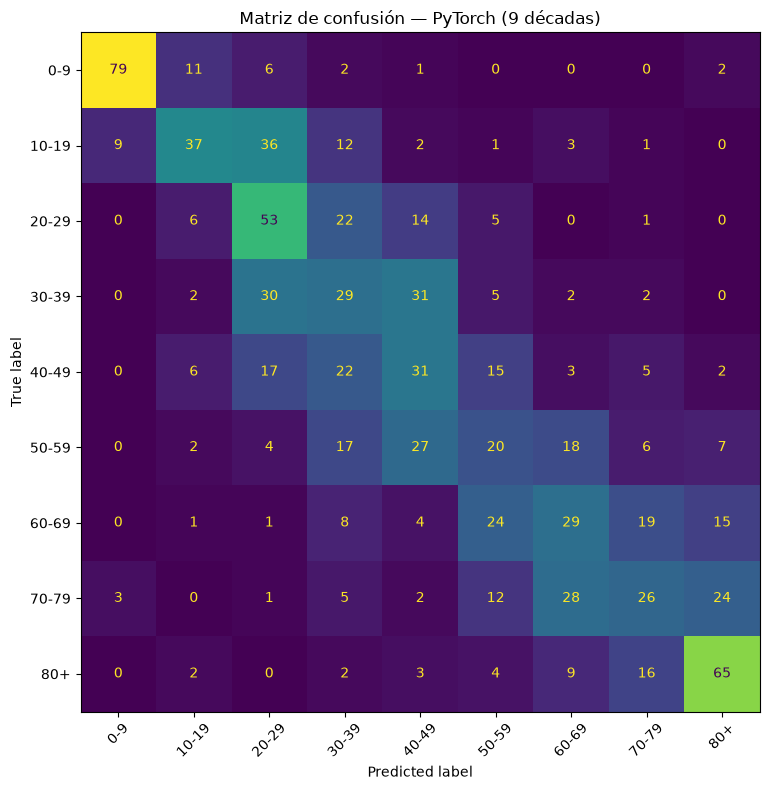

In [10]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — PyTorch (9 décadas)")
plt.tight_layout()
plt.show()

## Parte B — TensorFlow / Keras

In [11]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [12]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,161 (2.09 MB)

 Trainable params: 549,161 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# --- Entrenamiento (Keras) ---
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)

Epoch 1/10


C:\Users\fsali\Documents\GitHub\frameworks-ia-2026_udd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/133 ━━━━━━━━━━━━━━━━━━━━ 3:14 1s/step - accuracy: 0.1562 - loss: 2.1881

  6/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1042 - loss: 2.2273

 12/133 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1250 - loss: 2.2113

...

108/133 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5382 - loss: 1.1346

115/133 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5370 - loss: 1.1347

122/133 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5356 - loss: 1.1409

129/133 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5351 - loss: 1.1425

133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5355 - loss: 1.1403 - val_accuracy: 0.4323 - val_loss: 1.4112


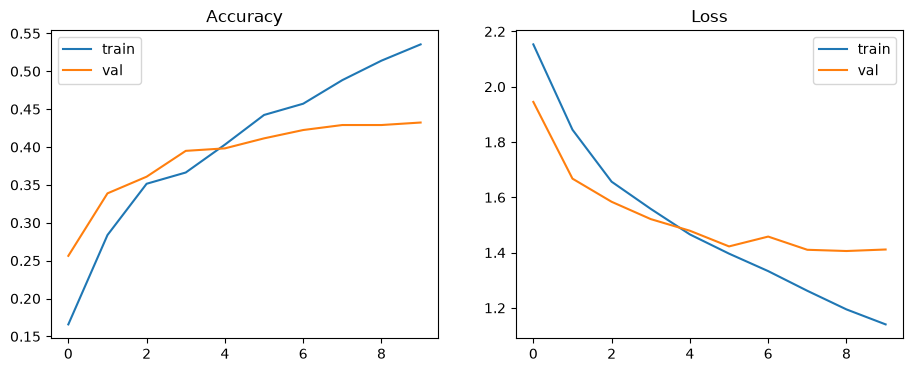

In [14]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

         0-9       0.82      0.82      0.82       101
       10-19       0.46      0.56      0.51       101
       20-29       0.43      0.45      0.44       101
       30-39       0.28      0.27      0.27       101
       40-49       0.26      0.17      0.20       101
       50-59       0.22      0.22      0.22       101
       60-69       0.24      0.21      0.22       101
       70-79       0.28      0.31      0.29       101
         80+       0.57      0.66      0.61       101

    accuracy                           0.41       909
   macro avg       0.40      0.41      0.40       909
weighted avg       0.40      0.41      0.40       909



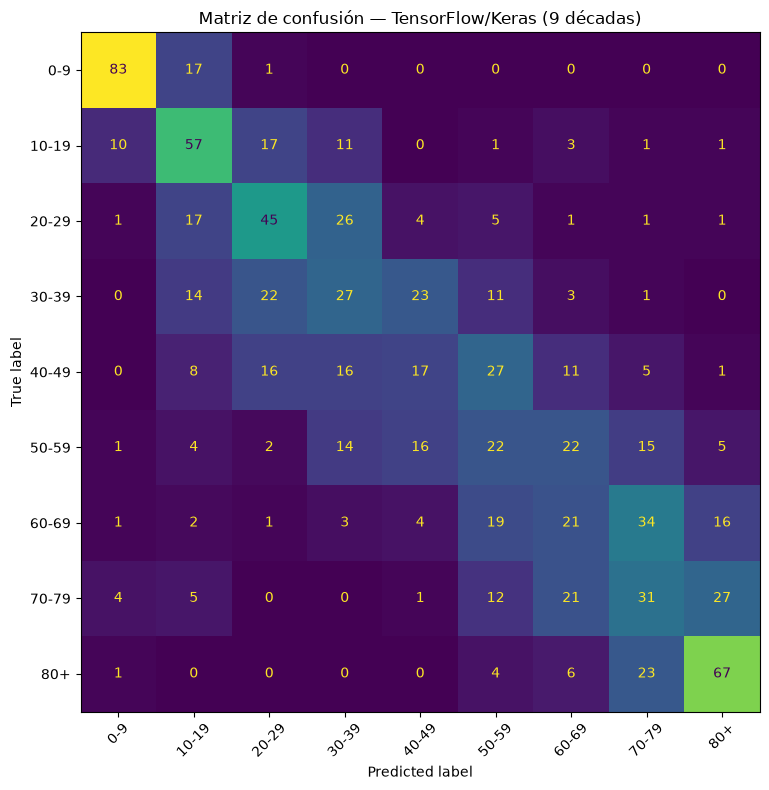

In [15]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — TensorFlow/Keras (9 décadas)")
plt.tight_layout()
plt.show()

## Comparación final

_(Completa aquí: accuracy de cada framework en test, qué clases se confunden más entre sí — probablemente 'joven' vs 'adulto' y 'adolescente' vs 'joven' por la ambigüedad visual en los límites de rango — y qué cambiarías para mejorar el modelo: más datos, balanceo de clases, augmentación, transfer learning, etc.)_